In [ ]:
!pip install quantile-forest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.5 MB/s eta 0:00:00


In [ ]:

# ====================================================================
# QRF (Quantile Regression Forest) for Hospital Admissions Prediction
# ====================================================================
# This script performs:
# 1. Data loading and feature engineering (lag variables + one‑hot city)
# 2. Chronological train/test split per city (no time leakage)
# 3. Standardization of features
# 4. QRF training (quantile predictions: 10th, 50th, 90th percentiles)
# 5. Model evaluation (MAE, RMSE, R², MAPE, 80% PI coverage)
# ====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from quantile_forest import RandomForestQuantileRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot style (optional, for later figures)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# -------------------------------------------------------------------
# 1. LOAD DATA & CREATE FEATURES
# -------------------------------------------------------------------
# Read the merged CSV file (make sure the date column is parsed if present)
df = pd.read_csv('merged_project_data.csv', parse_dates=['date'])

# Keep original city names for later splitting (before one‑hot encoding)
city_original_full = df['city'].copy()

# One‑hot encode city (create dummy variables)
df = pd.get_dummies(df, columns=['city'], prefix='city', drop_first=False)

# Define feature columns: air pollutants, lagged PM2.5, hospital capacity, and city dummies
feature_cols = [
    'pm25', 'pm10', 'o3', 'no2', 'so2', 'co',
    'pm25_lag1', 'pm25_lag2', 'pm25_lag3',
    'hospital_capacity'
] + [col for col in df.columns if col.startswith('city_')]

# Remove rows with missing values in any feature or target
mask = df[feature_cols].notna().all(axis=1) & df['hospital_admissions'].notna()
df_processed = df[mask].copy()
city_original_processed = city_original_full[mask].copy()

print("\nData preparation completed.")
print(f"Total rows after cleaning: {len(df_processed)}")

# -------------------------------------------------------------------
# 2. CHRONOLOGICAL TRAIN/TEST SPLIT (PER CITY)
# -------------------------------------------------------------------
# To avoid cross‑city contamination and preserve temporal order,
# we split each city's data separately (first 80% train, last 20% test).

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
city_test_list = []

for city_name in city_original_processed.unique():
    city_df = df_processed[city_original_processed == city_name].copy()
    X_city = city_df[feature_cols]
    y_city = city_df['hospital_admissions']
    n = len(X_city)
    split_idx = int(0.8 * n)          # first 80% for training
    X_train_list.append(X_city.iloc[:split_idx])
    X_test_list.append(X_city.iloc[split_idx:])
    y_train_list.append(y_city.iloc[:split_idx])
    y_test_list.append(y_city.iloc[split_idx:])
    city_test_list.append(city_original_processed[city_original_processed == city_name].iloc[split_idx:])

X_train = pd.concat(X_train_list).sort_index()
X_test = pd.concat(X_test_list).sort_index()
y_train = pd.concat(y_train_list).sort_index()
y_test = pd.concat(y_test_list).sort_index()
city_test = pd.concat(city_test_list).sort_index()

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

# -------------------------------------------------------------------
# 3. STANDARDIZE FEATURES (fit only on training data)
# -------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------------------------------------------
# 4. TRAIN QUANTILE REGRESSION FOREST (QRF)
# -------------------------------------------------------------------
qrf = RandomForestQuantileRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1          # use all CPU cores
)
qrf.fit(X_train_scaled, y_train)

# Predict quantiles: 10% (lower), 50% (median), 90% (upper)
quantiles = [0.1, 0.5, 0.9]
y_pred_quantiles = qrf.predict(X_test_scaled, quantiles=quantiles)
y_pred_lower = y_pred_quantiles[:, 0]
y_pred_median = y_pred_quantiles[:, 1]
y_pred_upper = y_pred_quantiles[:, 2]

# -------------------------------------------------------------------
# 5. EVALUATION METRICS
# -------------------------------------------------------------------
mae = mean_absolute_error(y_test, y_pred_median)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_median))
r2 = r2_score(y_test, y_pred_median)

# MAPE (avoid division by zero)
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_val = mape(y_test.values, y_pred_median)

# 80% Prediction Interval coverage
coverage = np.mean((y_test >= y_pred_lower) & (y_test <= y_pred_upper)) * 100

# Print only the essential numbers (no extra logs)
print("\n" + "="*50)
print("QRF MODEL PERFORMANCE")
print("="*50)
print(f"MAE  : {mae:.4f} patients/day")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape_val:.2f}%")
print(f"80% Prediction Interval Coverage: {coverage:.1f}%")
print("="*50)

# (Optional) You can keep the scaler, model, and predictions for later visualisation.
# The actual plotting (scatter, feature importance, prediction intervals) is typically
# done in a separate cell or script – not included here to keep the cell clean.


Data preparation completed.
Total rows after cleaning: 11611
Training samples: 9288
Test samples:     2323

QRF MODEL PERFORMANCE
MAE  : 3.0385 patients/day
RMSE : 4.1442
R²   : 0.9795
MAPE : 8.09%
80% Prediction Interval Coverage: 81.6%


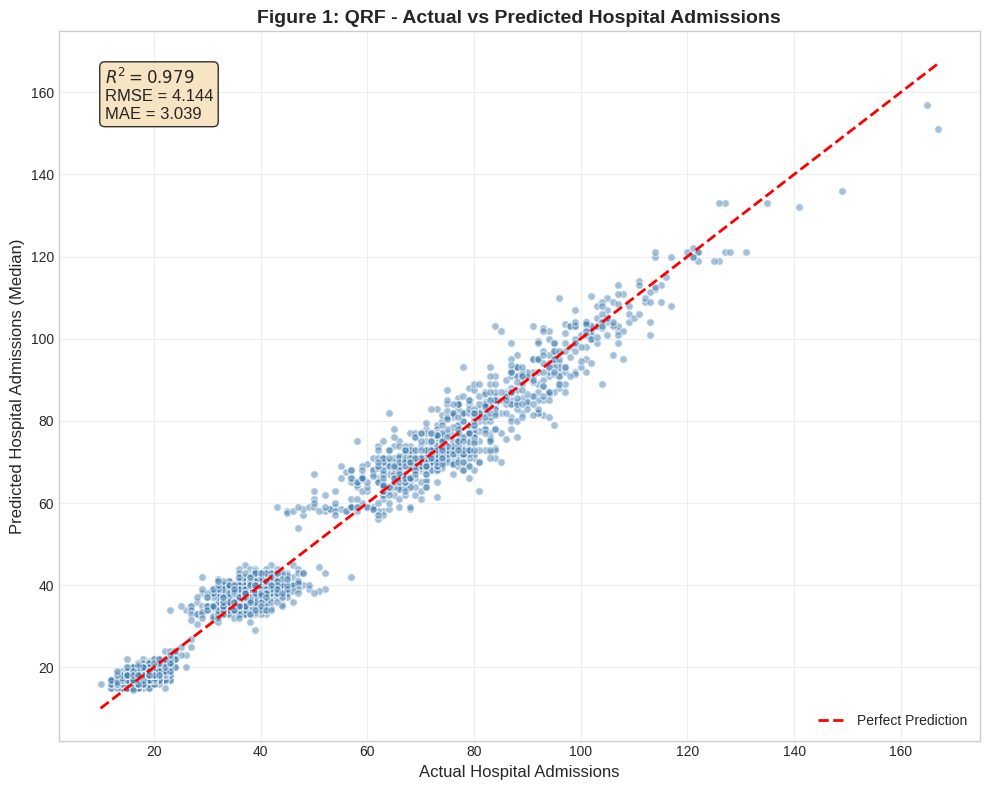

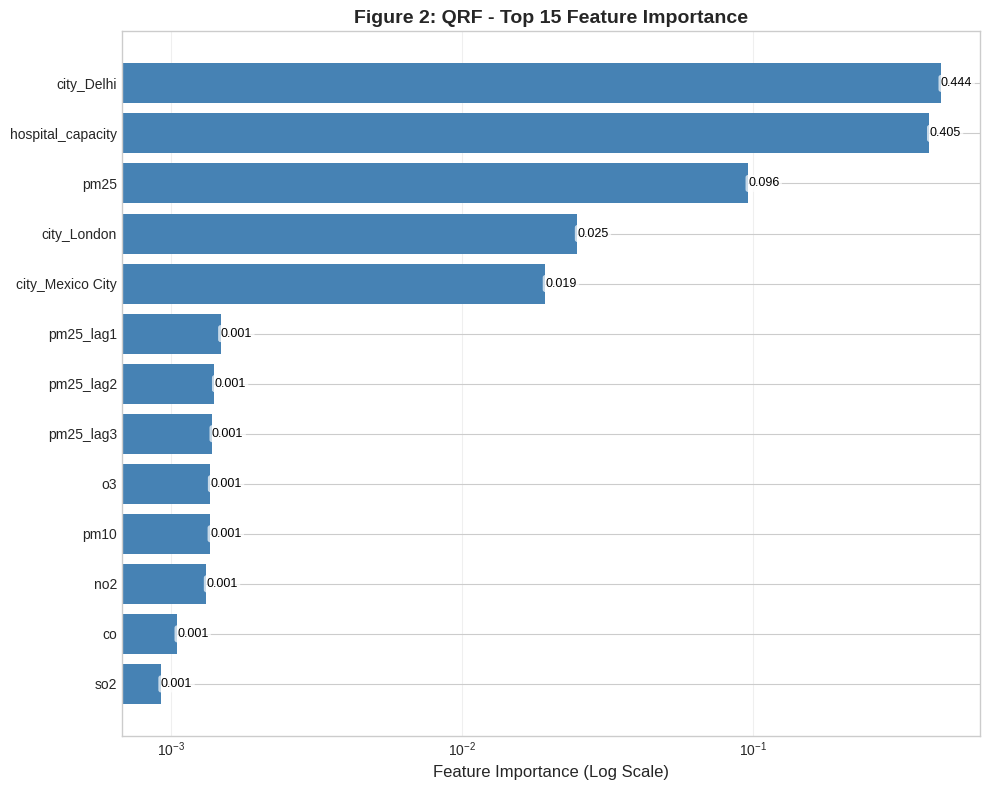

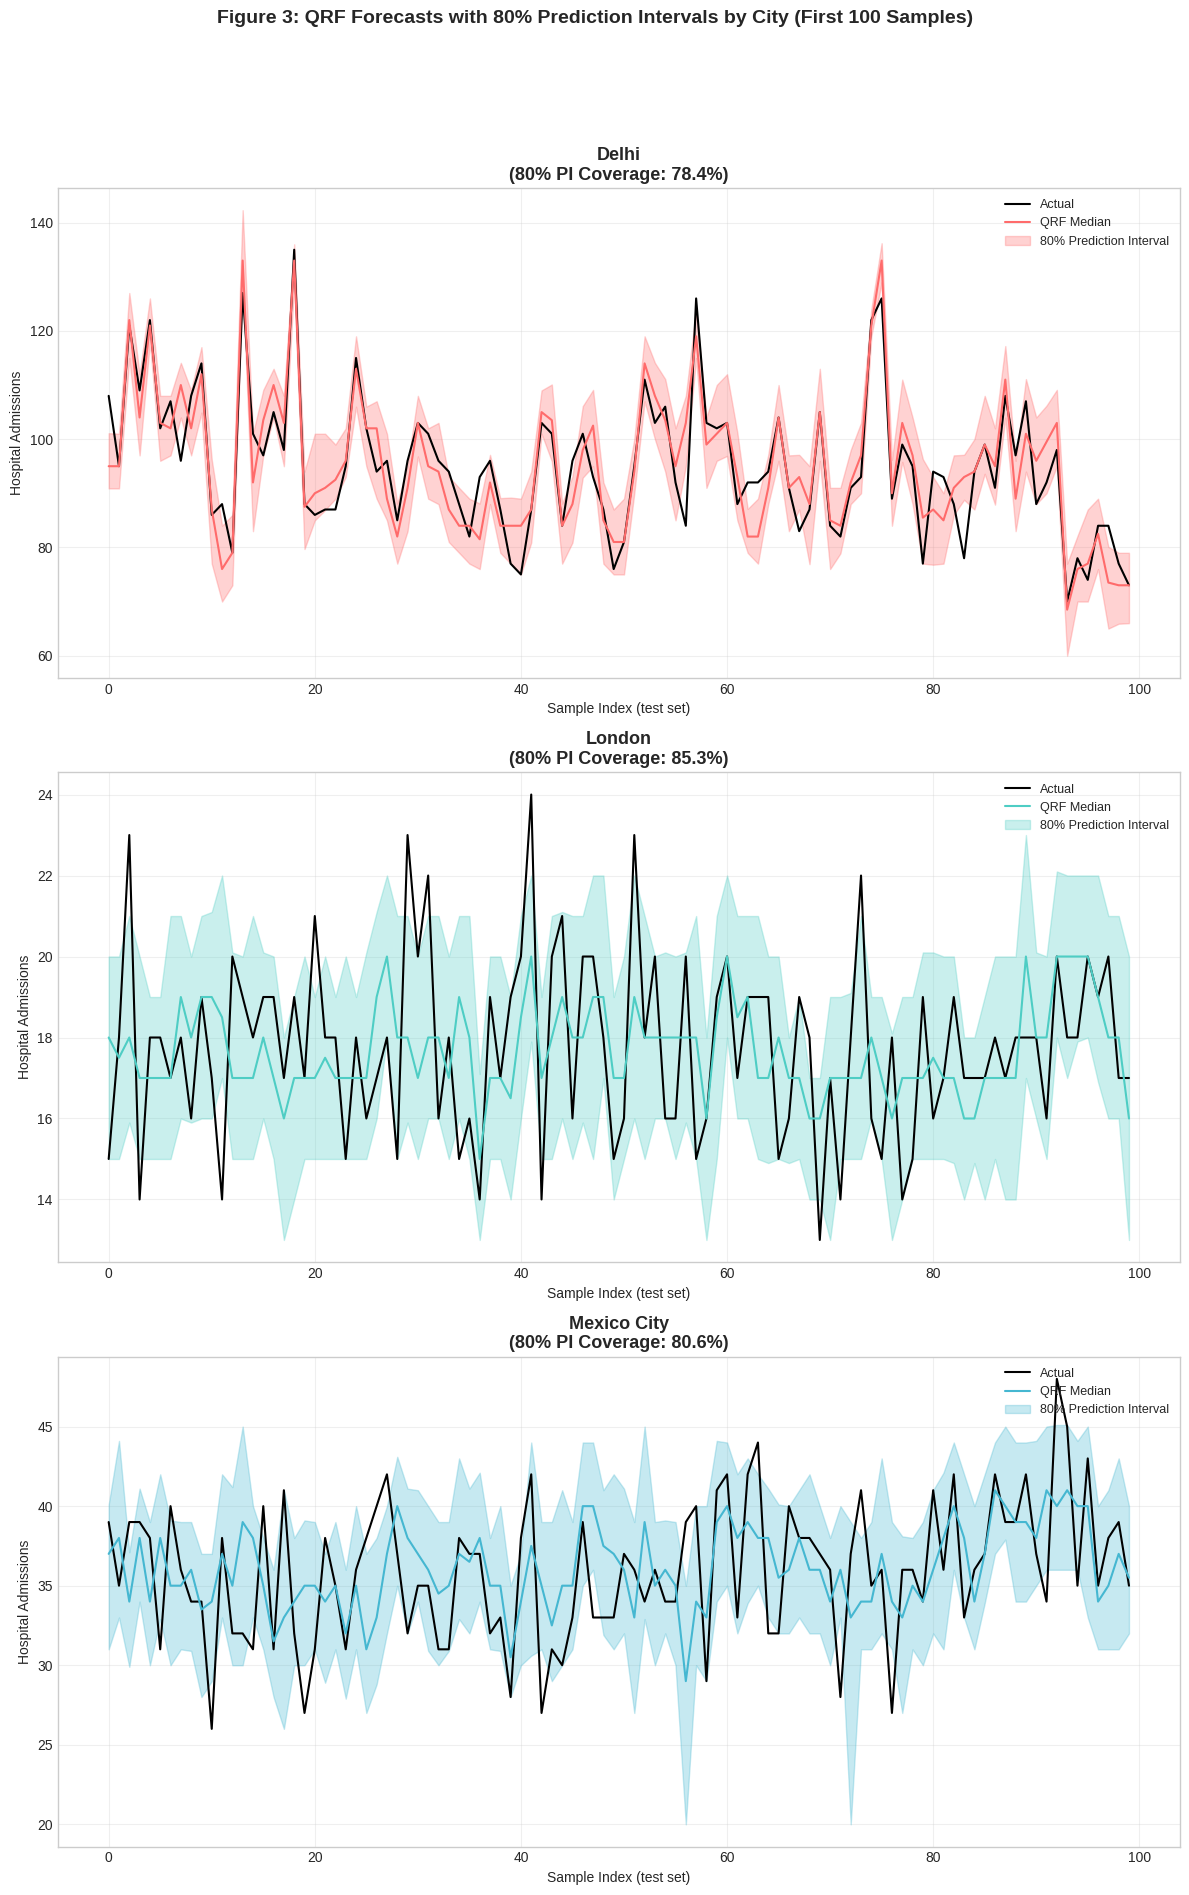

In [4]:
# ====================================================================
# QRF VISUALIZATIONS (Figures for report)
# ====================================================================
# This cell produces three figures:
# 1. Actual vs Predicted scatter plot (with perfect‑fit diagonal)
# 2. Top 15 feature importance (log‑scale bar chart)
# 3. Forecasts with 80% prediction intervals, shown separately for each city
# ====================================================================

import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# Figure 1: Actual vs Predicted (Median) Scatter Plot
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, y_pred_median, alpha=0.5, c='steelblue', edgecolors='white', s=30)

# Perfect prediction line
max_val = max(y_test.max(), y_pred_median.max())
min_val = min(y_test.min(), y_pred_median.min())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

# Annotate with performance metrics
ax.text(0.05, 0.95, f'$R^2 = {r2:.3f}$\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('Actual Hospital Admissions', fontsize=12)
ax.set_ylabel('Predicted Hospital Admissions (Median)', fontsize=12)
ax.set_title('Figure 1: QRF - Actual vs Predicted Hospital Admissions', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Figure 2: Feature Importance (Top 15)
# -------------------------------------------------------------------
feature_importance = qrf.feature_importances_
feature_names = X_train.columns
sorted_idx = np.argsort(feature_importance)[-15:]   # keep only top 15

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(sorted_idx)), feature_importance[sorted_idx], color='steelblue')
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('Feature Importance (Log Scale)', fontsize=12)
ax.set_title('Figure 2: QRF - Top 15 Feature Importance', fontsize=14, fontweight='bold')
ax.set_xscale('log')   # log scale because importance values span orders of magnitude
ax.grid(axis='x', alpha=0.3)

# Add numeric labels at the end of each bar
for bar, imp in zip(bars, feature_importance[sorted_idx]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f'{imp:.3f}', va='center', ha='left', fontsize=9, color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Figure 3: Prediction Intervals by City (first 100 test samples per city)
# -------------------------------------------------------------------
cities = ['Delhi', 'London', 'Mexico City']
city_colors = {'Delhi': '#FF6B6B', 'London': '#4ECDC4', 'Mexico City': '#45B7D1'}

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for idx, city in enumerate(cities):
    ax = axes[idx]
    city_mask = (city_test == city)

    # If no test data for this city, show informative message on subplot
    if not city_mask.any():
        ax.set_title(f'{city}\n(No test data available)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Sample Index (test set)')
        ax.set_ylabel('Hospital Admissions')
        ax.legend(loc='upper right')
        ax.grid(alpha=0.3)
        continue

    y_test_city = y_test[city_mask].values[:100]
    y_lower_city = y_pred_lower[city_mask][:100]
    y_median_city = y_pred_median[city_mask][:100]
    y_upper_city = y_pred_upper[city_mask][:100]

    ax.plot(y_test_city, label='Actual', color='black', linewidth=1.5)
    ax.plot(y_median_city, label='QRF Median', color=city_colors[city], linewidth=1.5)
    ax.fill_between(range(len(y_median_city)), y_lower_city, y_upper_city,
                    alpha=0.3, color=city_colors[city], label='80% Prediction Interval')

    # Compute coverage for this city (whole test set, not just first 100)
    coverage_city = np.mean((y_test[city_mask] >= y_pred_lower[city_mask]) &
                            (y_test[city_mask] <= y_pred_upper[city_mask])) * 100
    ax.set_title(f'{city}\n(80% PI Coverage: {coverage_city:.1f}%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Sample Index (test set)')
    ax.set_ylabel('Hospital Admissions')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Figure 3: QRF Forecasts with 80% Prediction Intervals by City (First 100 Samples)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()